## ADVANCED REGRESSION: DT Regressor

In [ ]:
#! pip install loguru


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
#! pip install torch


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [3]:
from sklearn.experimental import enable_halving_search_cv

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, HalvingGridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [ ]:
x_train = (pd.read_csv('data/regression/X_train_rating_no_out_regression.csv')).drop('Unnamed: 0', axis =1)
y_train = (pd.read_csv('data/regression/y_train_rating_no_out_regression.csv')).drop('Unnamed: 0', axis =1)

x_test = pd.read_csv('data/regression/X_test_rating_regression.csv')
y_test = pd.read_csv('data/regression/y_test_rating_regression.csv')

In [6]:
y_train = y_train['averageRating']
y_test = y_test['averageRating']

In [ ]:
folds = KFold(n_splits=3, shuffle = True, random_state= 42)

### Scaling and log transform

In [7]:
# log transformation delle seguenti colonne: runtimeminutes, numvotes, totalcredits, userrewtotal, totalmedia
cols = ['runtimeMinutes', 'numVotes', 'totalCredits', 'userReviewsTotal', 'totalMedia']

for col in cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])

In [ ]:
scaler = StandardScaler()
num_cols = ['startYear', 'runtimeMinutes', 'numVotes', 'totalCredits', 'criticReviewsTotal', 'numRegions', 'userReviewsTotal',
        'companiesNumber', 'averageRating', 'externalLinks', 'writerCredits',
        'directorsCredits', 'quotesTotal', 'totalMedia', 'totalNominations']

x_train[num_cols]= scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

### DUMMY REGRESSOR

In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

In [12]:
dummy = DummyRegressor(strategy= 'median')
dummy.fit(x_scaled, y_train)

y_pred_dummy = dummy.predict(x_test_scaled)

print(mean_squared_error(y_test, y_pred_dummy))
print(mean_absolute_error(y_test, y_pred_dummy))
print(r2_score(y_test, y_pred_dummy))

1.8439605922551252
1.0311138952164007
-0.026433601377207516


### SUPPORT VECTOR REGRESSOR

In [ ]:
svr = SVR(max_iter=10000)

svr_params = {
    'kernel' : ['poly', 'rbf', 'sigmoid'],
    'degree' : [2,3,4],
    'gamma' : [1e-1, 'auto', 1, 10],
    'C' : [0.1, 1, 10, 100],
    'epsilon' : [0.01, 0.1, 1]
}

In [ ]:
svr_grid = HalvingGridSearchCV(estimator=svr, 
                        param_grid=svr_params, 
                        cv = folds,
                        n_jobs = -1, 
                        scoring ='r2',
                        factor = 2, 
                        min_resources = 500,
                        max_resources = 'auto',
                        verbose= 1)

In [ ]:
svr_grid.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/l

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=SVR(max_iter=10000), n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'degree': [2, 3, 4],
                                        'epsilon': [0.01, 0.1, 1],
                                        'gamma': [0.1, 'auto', 1, 10],
                                        'kernel': ['poly', 'rbf', 'sigmoid']},
                   return_train_score=True, scoring='r2', verbose=1)

In [1]:
print('Migliori iperparametri per SVRegressor:', svr_grid.best_params_)
print('Miglior score CV per SVRegressor:', svr_grid.best_score_)

NameError: name 'svr_grid' is not defined

In [ ]:
svr_model = SVR(**svr_grid.best_params_)
svr_model.fit(x_train, y_train)
y_pred_svr = svr_model.predict(x_test)

Confronto delle metriche

In [ ]:
y_pred_train_svr = svr_model.predict(x_train)

mse_train_svr = mean_squared_error(y_train, y_pred_train_svr, multioutput='raw_values')
mae_train_svr = mean_absolute_error(y_train, y_pred_train_svr, multioutput='raw_values')
r2_train_svr = r2_score(y_train, y_pred_train_svr, multioutput='raw_values')

In [ ]:
print(f"🔍 Mean Squared Error (MSE) sul training set: {mse_train_svr}")
print(f"📉 Mean Absolute Error (MAE) sul training set: {mae_train_svr}")
print(f"📈 R-squared (R²) sul training set: {r2_train_svr}")

In [55]:
mse = mean_squared_error(y_test, y_pred_svr, multioutput='raw_values')
mae = mean_absolute_error(y_test, y_pred_svr, multioutput='raw_values')
r2 = r2_score(y_test, y_pred_svr, multioutput='raw_values')

In [56]:
print(f"🔍 Mean Squared Error (MSE): {mse}")
print(f"📉 Mean Absolute Error (MAE): {mae}")
print(f"📈 R-squared (R²): {r2}")

🔍 Mean Squared Error (MSE): [1.3389424]
📉 Mean Absolute Error (MAE): [0.87892028]
📈 R-squared (R²): [0.25468284]


In [57]:
model_path = "/Applications/OneDrive.app"
import joblib

In [58]:
joblib.dump(
   svr_model,
    model_path + 'svr_dm2'+ '.pkl'
)

['/Applications/OneDrive.appsvr_dm2.pkl']

### RANDOM FOREST REGRESSOR

In [ ]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators' : [10, 100],
    'criterion' : ['squared_error', 'absolute_error'],
    'max_depth' : [10, 50, 100, None],
    'min_samples_split' :[2, 5, 10],
    'min_samples_leaf' : [1, 5, 10], 
}

In [ ]:
rf_grid = HalvingGridSearchCV(estimator=rf,
                       param_grid=rf_params, 
                       cv = folds,
                       n_jobs = -1, 
                        scoring='r2',
                        min_resources=500,
                        max_resources='auto',
                        verbose= 1)

In [13]:
rf_grid.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [ ]:
print('Migliori iperparametri per RFRegressor:', rf_grid.best_params_)
print('Miglior score CV per RFRegressor:', rf_grid.best_score_)

In [ ]:
rf_model = RandomForestRegressor(rf_grid.best_params_, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

Confronto delle metriche

In [ ]:
y_pred_train_rf = rf_model.predict(x_train)

mse_train_rf = mean_squared_error(y_train, y_pred_train_rf, multioutput='raw_values')
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf, multioutput='raw_values')
r2_train_rf = r2_score(y_train, y_pred_train_rf, multioutput='raw_values')

In [ ]:
print(f"🔍 Mean Squared Error (MSE) sul training set: {mse_train_rf}")
print(f"📉 Mean Absolute Error (MAE) sul training set: {mae_train_rf}")
print(f"📈 R-squared (R²) sul training set: {r2_train_rf}")

In [ ]:
mse_rf = mean_squared_error(y_test, y_pred_rf, multioutput='raw_values')
mae_rf = mean_absolute_error(y_test, y_pred_rf, multioutput='raw_values')
r2_rf = r2_score(y_test, y_pred_rf, multioutput='raw_values')

In [ ]:
print(f"🔍 Mean Squared Error (MSE): {mse_rf}")
print(f"📉 Mean Absolute Error (MAE): {mae_rf}")
print(f"📈 R-squared (R²): {r2_rf}")

🔍 Mean Squared Error (MSE): [1.090006]
📉 Mean Absolute Error (MAE): [0.75464625]
📈 R-squared (R²): [0.39325233]


In [ ]:
joblib.dump(
   rf_model,
    model_path + 'rf_dm2'+ '.pkl'
)

### PYTORCH NN

In [ ]:
! pip install torchsummary
! pip install pytorch-ignite


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [78]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torchsummary import summary
from torch.nn.init import xavier_normal_
from torch.utils.data import TensorDataset, DataLoader
from loguru import logger

from ignite.metrics import MeanSquaredError, MeanAbsoluteError, Metric


In [ ]:
# Creazione del set di validation
x_train_split, x_val, y_train_split, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

1) Preparazione dei dati alla rete pytorch: le reti pytorch utilizzano i tensori, speciali strutture dato usate per codificare input, output e parametri del modello. Sono molto simili ad array e matrici, sono ottimizzati per il lavoro sulle GPU poiché facilmente differenziabili. Corrispondono ad un array numpy.

In [ ]:
x_train_tensor = torch.tensor(x_train_split, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split, dtype=torch.float32)

x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

I tensori sono inseriti all'interno di un'altra struttura dati nativa di pytorch: il Dataset. Pytorch non riesce a leggere un df pandas.

In [81]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

Dataset a cui si può facilmente accedere tramite la classe DataLoader, permetto uso immediato al momento del training.

In [82]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

2) Costruzione del modello. Pytorch utilizza una classe specifica con oggetti nativi per la costruzione delle reti. Questa classe si chiama Module e fa parte del modulo nn di Pytorch, la utilizziamo per impostare gli strati, il numero di neuroni per strato e la funzione di attivazione di ogni neurone. 
Pytorch invita all'utilizzo di classi anche nel proprio codice.

In [84]:
class NNRegressor(nn.Module):

    def __init__(self, input_dim, hidden_size, output_size):
        super(NNRegressor, self).__init__()

        self.input_layer = nn.Linear(input_dim, hidden_size)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, output_size)

        self.relu = nn.ReLU()

    # Applicazione delle funzioni di attivazione per ogni strato
    def forward(self, x):
        x = self.relu(self.input_layer(x))
        x = self.relu(self.hidden_layer(x))
        x = self.output_layer(x)

        return x

3) Definizione degli iperparametri. Dobbiamo definire la dimensione in neuroni dell'input (input_dim nella classe sopra), dello strato nascosto (hidden_size) e dello strato di output (output_size).

In [85]:
input_size = x_scaled.shape[1] # ci devono essere tanti neuroni quante istanze da considerare
hidden_size = 32
output_size = 1 # settato ad 1 perché l'output della regressione deve essere un singolo valore

4) Istanziamo il modello con early stopping

In [86]:
from ignite.handlers import EarlyStopping, ModelCheckpoint
from ignite.contrib.handlers import global_step_from_engine
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator

In [87]:
model = NNRegressor(input_size, hidden_size, output_size)

In [88]:
summary(model, input_size= (input_size,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 32]           1,888
              ReLU-2                   [-1, 32]               0
            Linear-3                   [-1, 32]           1,056
              ReLU-4                   [-1, 32]               0
            Linear-5                    [-1, 1]              33
Total params: 2,977
Trainable params: 2,977
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


5) Istanziamo l'ottimizzatore e la loss

In [89]:
optimizer = optim.Adam(model.parameters(), lr= 0.01)
criterion = nn.MSELoss()

6) Istanziamo l'ignite engine trainer per incorporare le sue funzioni di perdita

In [90]:
class R2Score(Metric):
    def __init__(self, output_transform=lambda x: x, device=None):
        super(R2Score, self).__init__(output_transform=output_transform, device=device)

    def reset(self):
        self.sum_squared_residuals = 0.0
        self.sum_squared_totals = 0.0
        self._y_true = []
        self._y_pred = []

    def update(self, output):
        y_pred, y_true = output
        y_pred = y_pred.detach()
        y_true = y_true.detach()

        self._y_pred.append(y_pred)
        self._y_true.append(y_true)

    def compute(self):
        y_pred = torch.cat(self._y_pred)
        y_true = torch.cat(self._y_true)
        y_mean = torch.mean(y_true)

        ss_res = torch.sum((y_true - y_pred) ** 2)
        ss_tot = torch.sum((y_true - y_mean) ** 2)

        r2 = 1 - ss_res / ss_tot
        return r2.item()

In [91]:
trainer = create_supervised_trainer(model, optimizer, criterion, device)

In [92]:
val_metrics = {"mean_squared_error": MeanSquaredError(device=device), "mean_absolute_error": MeanAbsoluteError(device=device), 'r2': R2Score(device=device)}

# ignite train and validation evaluators
train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

training_history = {'mean_squared_error':[],'mean_absolute_error':[], 'r2' :[] }
validation_history = {'mean_squared_error':[],'mean_absolute_error':[], 'r2': []}

In [93]:
# For logging purposes we add a function to be executed at the end of every log_interval-th iteration:
log_interval = 100

@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.2f}")

# after a training epoch, computes training and validation metrics (train_eval on train_loader and val_eval on val_loader)
@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    training_history['mean_squared_error'].append(metrics['mean_squared_error'])
    training_history['mean_absolute_error'].append(metrics['mean_absolute_error'])
    training_history['r2'].append(metrics['r2'])
    print(f"Training Results - Epoch[{trainer.state.epoch}] MeanSquaredError: {metrics['mean_squared_error']:.2f} MeanAbsoluteError: {metrics['mean_absolute_error']:.2f} R2: {metrics['r2']:.2f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    validation_history['mean_squared_error'].append(metrics['mean_squared_error'])
    validation_history['mean_absolute_error'].append(metrics['mean_absolute_error'])
    validation_history['r2'].append(metrics['r2'])
    print(f"Validation Results - Epoch[{trainer.state.epoch}] MeanSquaredError: {metrics['mean_squared_error']:.2f} MeanAbsoluteError: {metrics['mean_absolute_error']:.2f} R2: {metrics['r2']:.2f}")

7. Definizione early stopping

In [94]:
def score_function(engine):
    y_pred, y_true = engine.state.output
    return r2_score(y_true.cpu().numpy(), y_pred.cpu().numpy())

In [95]:
handler = EarlyStopping(patience = 50, score_function=score_function, trainer = trainer)

checkpoint = ModelCheckpoint(dirname='models',
    filename_prefix='best_NOREG',
    n_saved=1,
    create_dir=True,
    global_step_transform=global_step_from_engine(trainer))

val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)
val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, checkpoint, {'model': model})

In [ ]:
trainer.run(train_loader, max_epochs=300)

Epoch[1], Iter[100] Loss: 1.97


/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch[1], Iter[200] Loss: 3.23
Epoch[1], Iter[300] Loss: 2.12
Epoch[1], Iter[400] Loss: 1.03
Epoch[1], Iter[500] Loss: 1.42
Epoch[1], Iter[600] Loss: 1.30
Epoch[1], Iter[700] Loss: 2.33
Epoch[1], Iter[800] Loss: 2.92
Epoch[1], Iter[900] Loss: 1.75
Epoch[1], Iter[1000] Loss: 2.54
Epoch[1], Iter[1100] Loss: 3.00
Epoch[1], Iter[1200] Loss: 1.85
Epoch[1], Iter[1300] Loss: 0.68
Epoch[1], Iter[1400] Loss: 2.06
Epoch[1], Iter[1500] Loss: 2.01
Epoch[1], Iter[1600] Loss: 1.53
Epoch[1], Iter[1700] Loss: 1.39
Epoch[1], Iter[1800] Loss: 2.06
Epoch[1], Iter[1900] Loss: 1.67
Epoch[1], Iter[2000] Loss: 1.36
Epoch[1], Iter[2100] Loss: 1.39
Epoch[1], Iter[2200] Loss: 1.60


/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


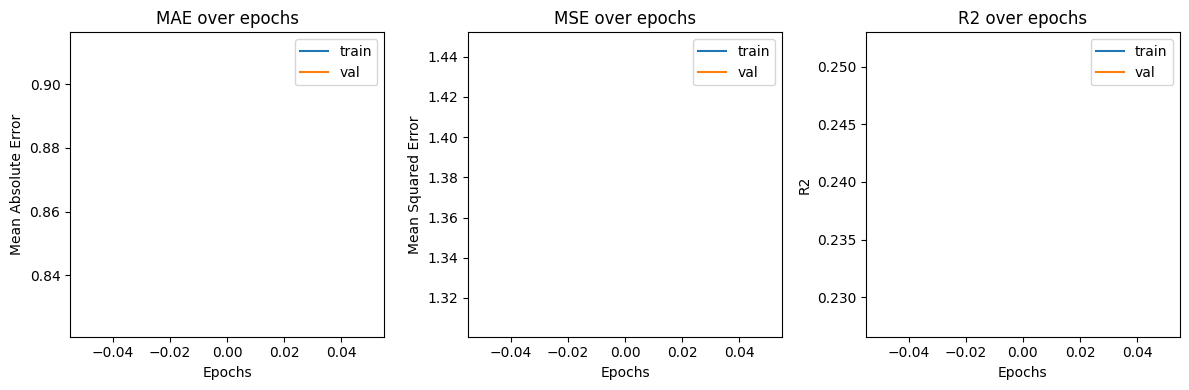

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

# Plot MAE
axes[0].plot(training_history['mean_absolute_error'], label='train')
axes[0].plot(validation_history['mean_absolute_error'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('MAE over epochs')
axes[0].legend()

# Plot MSE
axes[1].plot(training_history['mean_squared_error'], label='train')
axes[1].plot(validation_history['mean_squared_error'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('MSE over epochs')
axes[1].legend()

# Plot R2
axes[2].plot(training_history['r2'], label='train')
axes[2].plot(validation_history['r2'], label='val')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('R2')
axes[2].set_title('R2 over epochs')
axes[2].legend()

fig.tight_layout()
plt.show()
